# Sprint 4.1 - Comparing TLS Distributions with Field-Data Models

In [6]:
# ------------------------
# IMPORTS
# ------------------------

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [7]:
# ------------------------
# SETUP & DATA LOADING
# ------------------------

# Load tree data
field_data = pd.read_csv("./data/03_tree.csv")
tls_data = pd.read_csv("./data/TLS_treelist.csv")
ref_species = pd.read_csv("./data/REF_SPECIES.csv")
pft_codes = pd.read_csv("./data/FIATreeSpeciesCode_pft.csv")

In [8]:
# ------------------------
# DATA CLEANING
# ------------------------

# Map SPCD from species name
ref_species["scientific_name"] = ref_species["GENUS"] + " " + ref_species["SPECIES"]
name_to_spcd = dict(zip(ref_species["scientific_name"], ref_species["SPCD"]))
field_data["SPCD"] = field_data["tree_sp_scientific_name"].map(name_to_spcd)

# Join PFT codes
field_data = field_data.merge(ref_species[["SPCD", "GENUS"]], on="SPCD", how="left")
field_data = field_data.merge(pft_codes, on="SPCD", how="left")

# Rename for consistency
field_data["HT"] = field_data["tree_ht"]
field_data["DBH"] = field_data["tree_dbh"]
field_data["CBH"] = field_data["tree_htlcb"]

# Drop rows with missing labels or features
field_data = field_data.dropna(subset=["HT", "DBH", "CBH", "PFT", "GENUS", "SPCD"])

In [9]:
# ------------------------
# RANDOM FOREST MODEL TRAINING FUNCTION
# ------------------------
def train_and_evaluate_classifier(df, target, label_map=None):
    X = df[["HT", "DBH"]]
    y = df[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print(f"\n=== {target} CLASSIFICATION REPORT ===")
    if label_map:
        labels = sorted(y.unique())
        names = [label_map.get(l, f"{l}") for l in labels]
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(xticks_rotation=90)
        plt.title(f"Confusion Matrix for {target}")
        plt.show()
    print(classification_report(y_test, y_pred))
    return model


# ------------------------
# LOGISTIC REGRESSION TRAINING FUNCTION
# ------------------------

from sklearn.linear_model import LogisticRegression

def train_and_evaluate_logistic(df, target, label_map=None):
    X = df[["HT", "DBH"]]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression(max_iter=1000, multi_class='auto', solver='lbfgs')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"\n=== {target} LOGISTIC REGRESSION REPORT ===")
    if label_map:
        labels = sorted(y.unique())
        names = [label_map.get(l, f"{l}") for l in labels]
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(xticks_rotation=90)
        plt.title(f"Confusion Matrix for {target}")
        plt.show()
    print(classification_report(y_test, y_pred))
    return model


# ------------------------
# ADABOOST TRAINING FUNCTION
# ------------------------
from sklearn.ensemble import AdaBoostClassifier
def train_and_evaluate_adaboost(df, target, label_map=None):
    X = df[["HT", "DBH"]]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = AdaBoostClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f"\n=== {target} ADABOOST REPORT ===")
    if label_map:
        labels = sorted(y.unique())
        names = [label_map.get(l, f"{l}") for l in labels]
        cm = confusion_matrix(y_test, y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(cm, display_labels=names)
        disp.plot(xticks_rotation=90)
        plt.title(f"Confusion Matrix for {target}")
        plt.show()
    print(classification_report(y_test, y_pred))
    return model


# Label mappings for readable confusion matrices
spcd_to_common = dict(zip(ref_species["SPCD"], ref_species["COMMON_NAME"]))
genus_map = dict(zip(ref_species["GENUS"], ref_species["GENUS"]))
pft_map = dict(zip(pft_codes["PFT"], pft_codes["PFT"]))


=== PFT CLASSIFICATION REPORT ===


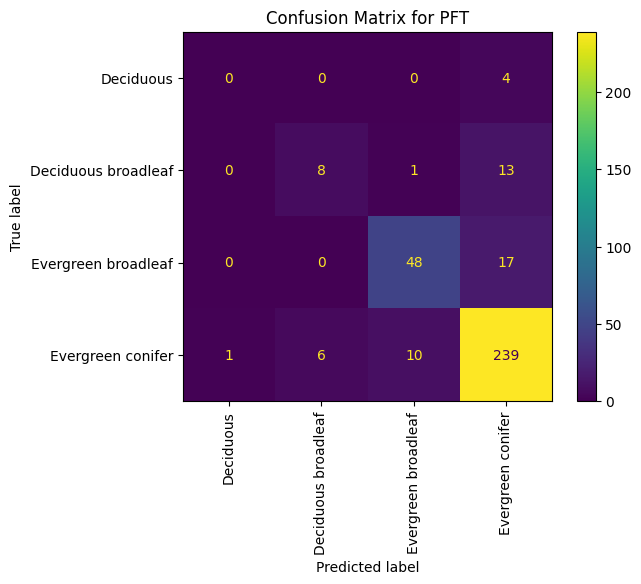

                     precision    recall  f1-score   support

          Deciduous       0.00      0.00      0.00         4
Deciduous broadleaf       0.57      0.36      0.44        22
Evergreen broadleaf       0.81      0.74      0.77        65
  Evergreen conifer       0.88      0.93      0.90       256

           accuracy                           0.85       347
          macro avg       0.57      0.51      0.53       347
       weighted avg       0.83      0.85      0.84       347


=== GENUS CLASSIFICATION REPORT ===
                precision    recall  f1-score   support

         Abies       0.35      0.37      0.36        84
          Acer       0.00      0.00      0.00         0
       Arbutus       0.00      0.00      0.00        11
    Calocedrus       0.48      0.45      0.47        89
         Pinus       0.46      0.49      0.47        68
       Populus       0.00      0.00      0.00         3
   Pseudotsuga       0.15      0.21      0.18        14
       Quercus       0.

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_


=== SPCD CLASSIFICATION REPORT ===


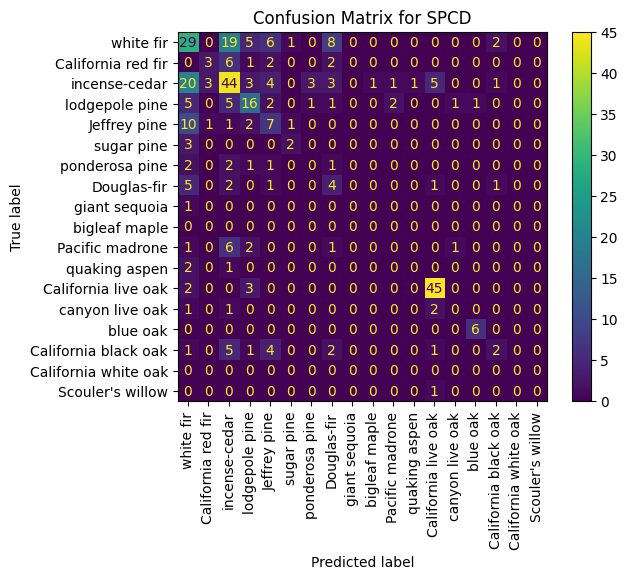

              precision    recall  f1-score   support

        15.0       0.35      0.41      0.38        70
        20.0       0.43      0.21      0.29        14
        81.0       0.48      0.49      0.49        89
       108.0       0.47      0.47      0.47        34
       116.0       0.26      0.32      0.29        22
       117.0       0.50      0.40      0.44         5
       122.0       0.00      0.00      0.00         7
       202.0       0.18      0.29      0.22        14
       212.0       0.00      0.00      0.00         1
       312.0       0.00      0.00      0.00         0
       361.0       0.00      0.00      0.00        11
       746.0       0.00      0.00      0.00         3
       801.0       0.82      0.90      0.86        50
       805.0       0.00      0.00      0.00         4
       807.0       0.86      1.00      0.92         6
       818.0       0.33      0.12      0.18        16
       928.0       0.00      0.00      0.00         1

    accuracy              

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_

In [10]:
# ------------------------
# MODELING TASKS - RANDOM FOREST
# ------------------------
# Task 1: Predict PFT
pft_model_classifier = train_and_evaluate_classifier(field_data, "PFT", pft_map)

# Task 2: Predict GENUS
genus_model_classifier = train_and_evaluate_classifier(field_data, "GENUS")

# Task 3: Predict SPCD (Species)
species_model_classifier = train_and_evaluate_classifier(field_data, "SPCD", spcd_to_common)

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== PFT LOGISTIC REGRESSION REPORT ===


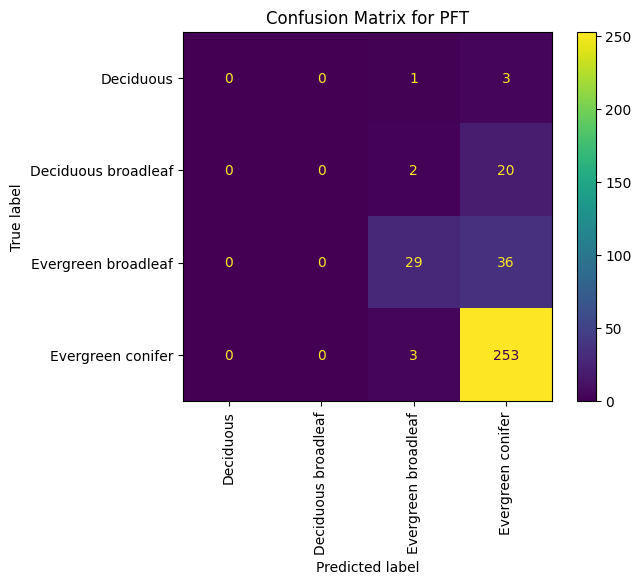

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/l

                     precision    recall  f1-score   support

          Deciduous       0.00      0.00      0.00         4
Deciduous broadleaf       0.00      0.00      0.00        22
Evergreen broadleaf       0.83      0.45      0.58        65
  Evergreen conifer       0.81      0.99      0.89       256

           accuracy                           0.81       347
          macro avg       0.41      0.36      0.37       347
       weighted avg       0.75      0.81      0.77       347



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre


=== GENUS LOGISTIC REGRESSION REPORT ===
                precision    recall  f1-score   support

         Abies       0.26      0.32      0.29        84
       Arbutus       0.00      0.00      0.00        11
    Calocedrus       0.33      0.39      0.36        89
         Pinus       0.32      0.13      0.19        68
       Populus       0.00      0.00      0.00         3
   Pseudotsuga       0.27      0.21      0.24        14
       Quercus       0.45      0.59      0.51        76
         Salix       0.00      0.00      0.00         1
Sequoiadendron       0.00      0.00      0.00         1

      accuracy                           0.34       347
     macro avg       0.18      0.18      0.18       347
  weighted avg       0.32      0.34      0.32       347



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== SPCD LOGISTIC REGRESSION REPORT ===


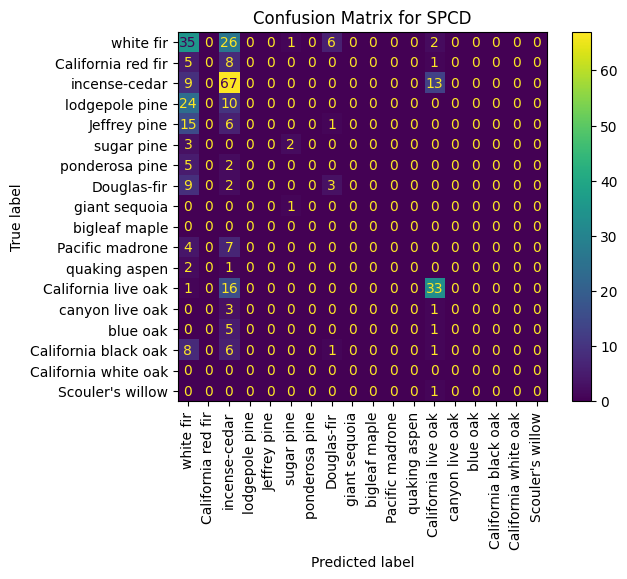

              precision    recall  f1-score   support

        15.0       0.29      0.50      0.37        70
        20.0       0.00      0.00      0.00        14
        81.0       0.42      0.75      0.54        89
       108.0       0.00      0.00      0.00        34
       116.0       0.00      0.00      0.00        22
       117.0       0.50      0.40      0.44         5
       122.0       0.00      0.00      0.00         7
       202.0       0.27      0.21      0.24        14
       212.0       0.00      0.00      0.00         1
       361.0       0.00      0.00      0.00        11
       746.0       0.00      0.00      0.00         3
       801.0       0.62      0.66      0.64        50
       805.0       0.00      0.00      0.00         4
       807.0       0.00      0.00      0.00         6
       818.0       0.00      0.00      0.00        16
       928.0       0.00      0.00      0.00         1

    accuracy                           0.40       347
   macro avg       0.13   

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
# ------------------------
# MODELING TASKS - LOGISTIC REG
# ------------------------
# Task 1: Predict PFT
pft_model_logistic = train_and_evaluate_logistic(field_data, "PFT", pft_map)

# Task 2: Predict GENUS
genus_model_logistic = train_and_evaluate_logistic(field_data, "GENUS")

# Task 3: Predict SPCD (Species)
species_model_logistic = train_and_evaluate_logistic(field_data, "SPCD", spcd_to_common)


=== PFT ADABOOST REPORT ===


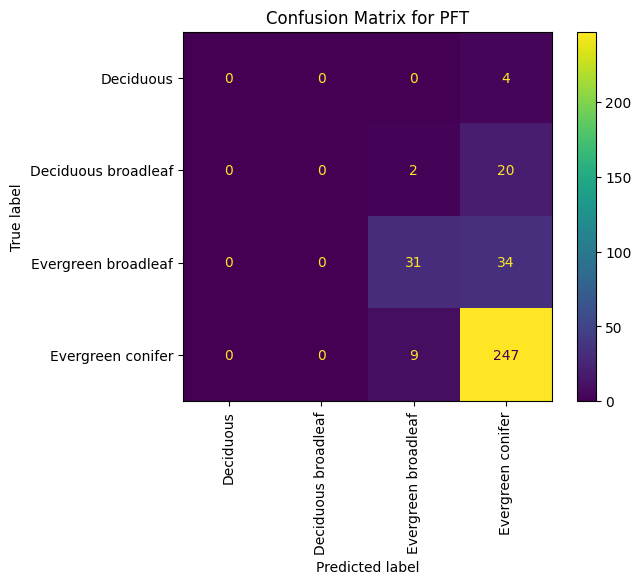

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                     precision    recall  f1-score   support

          Deciduous       0.00      0.00      0.00         4
Deciduous broadleaf       0.00      0.00      0.00        22
Evergreen broadleaf       0.74      0.48      0.58        65
  Evergreen conifer       0.81      0.96      0.88       256

           accuracy                           0.80       347
          macro avg       0.39      0.36      0.37       347
       weighted avg       0.74      0.80      0.76       347


=== GENUS ADABOOST REPORT ===
                precision    recall  f1-score   support

         Abies       0.23      0.11      0.15        84
       Arbutus       0.00      0.00      0.00        11
    Calocedrus       0.39      0.42      0.40        89
         Pinus       0.32      0.69      0.43        68
       Populus       0.00      0.00      0.00         3
   Pseudotsuga       0.00      0.00      0.00        14
       Quercus       0.43      0.36      0.39        76
         Salix       0.00    

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== SPCD ADABOOST REPORT ===


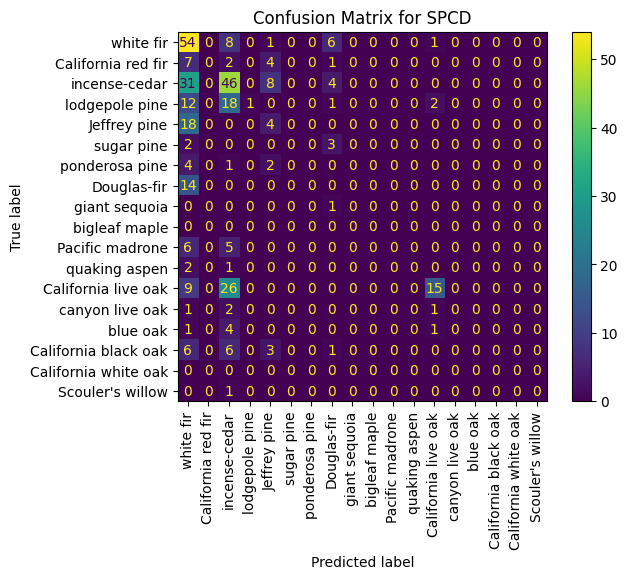

              precision    recall  f1-score   support

        15.0       0.32      0.77      0.46        70
        20.0       0.00      0.00      0.00        14
        81.0       0.38      0.52      0.44        89
       108.0       1.00      0.03      0.06        34
       116.0       0.18      0.18      0.18        22
       117.0       0.00      0.00      0.00         5
       122.0       0.00      0.00      0.00         7
       202.0       0.00      0.00      0.00        14
       212.0       0.00      0.00      0.00         1
       361.0       0.00      0.00      0.00        11
       746.0       0.00      0.00      0.00         3
       801.0       0.75      0.30      0.43        50
       805.0       0.00      0.00      0.00         4
       807.0       0.00      0.00      0.00         6
       818.0       0.00      0.00      0.00        16
       928.0       0.00      0.00      0.00         1

    accuracy                           0.35       347
   macro avg       0.16   

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
# ------------------------
# MODELING TASKS - RANDOM FOREST
# ------------------------
# Task 1: Predict PFT
pft_model_adaboost = train_and_evaluate_adaboost(field_data, "PFT", pft_map)

# Task 2: Predict GENUS
genus_model_adaboost = train_and_evaluate_adaboost(field_data, "GENUS")

# Task 3: Predict SPCD (Species)
species_model_adaboost = train_and_evaluate_adaboost(field_data, "SPCD", spcd_to_common)

In [14]:
# ------------------------
# APPLY TO TLS DATA
# ------------------------

tls_data["HT"] = tls_data["H"]
tls_data["DBH"] = tls_data["DBH"] * 2.54  # inches → cm

# Predict using trained models -- Forest
tls_data["PFT_pred_Forest"] = pft_model_classifier.predict(tls_data[["HT", "DBH"]].fillna(0))
tls_data["GENUS_pred_Forest"] = genus_model_classifier.predict(tls_data[["HT", "DBH"]].fillna(0))
tls_data["SPCD_pred_Forest"] = species_model_classifier.predict(tls_data[["HT", "DBH"]].fillna(0))

# Predict using trained models -- Logistic
tls_data["PFT_pred_Logistic"] = pft_model_logistic.predict(tls_data[["HT", "DBH"]].fillna(0))
tls_data["GENUS_pred_Logistic"] = genus_model_logistic.predict(tls_data[["HT", "DBH"]].fillna(0))
tls_data["SPCD_pred_Logistic"] = species_model_logistic.predict(tls_data[["HT", "DBH"]].fillna(0))

# Predict using trained models -- AdaBoost
tls_data["PFT_pred_Adaboost"] = pft_model_adaboost.predict(tls_data[["HT", "DBH"]].fillna(0))
tls_data["GENUS_pred_Adaboost"] = genus_model_adaboost.predict(tls_data[["HT", "DBH"]].fillna(0))
tls_data["SPCD_pred_Adaboost"] = species_model_adaboost.predict(tls_data[["HT", "DBH"]].fillna(0))

In [23]:
# ------------------------
# DISTRIBUTION COMPARISON -- PFT
# ------------------------

# Get proportion distributions for each method
forest_dist = tls_data["PFT_pred_Forest"].value_counts(normalize=True)
logistic_dist = tls_data["PFT_pred_Logistic"].value_counts(normalize=True)
adaboost_dist = tls_data["PFT_pred_Adaboost"].value_counts(normalize=True)
observed_dist = field_data["PFT"].value_counts(normalize=True)

# Combine into a single DataFrame
pft_dist_df = pd.DataFrame({
    "Random Forest": forest_dist,
    "Logistic": logistic_dist,
    "AdaBoost": adaboost_dist,
    "Observed (Field)": observed_dist
})

pft_dist_df = pft_dist_df.fillna(0)
pft_dist_df = pft_dist_df.sort_values("Observed (Field)", ascending=False)
pft_dist_df = pft_dist_df.applymap(lambda x: f"{x*100:.2f}%")
pft_dist_df

/tmp/ipykernel_382/529722180.py:31: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  pft_dist_df = pft_dist_df.applymap(lambda x: f"{x*100:.2f}%")


,Random Forest,Logistic,AdaBoost,Observed (Field)
Evergreen conifer,85.31%,89.58%,84.80%,71.92%
Evergreen broadleaf,12.81%,10.42%,15.20%,20.22%
Deciduous broadleaf,1.81%,0.00%,0.00%,6.99%
Deciduous,0.07%,0.00%,0.00%,0.87%


In [22]:
# ------------------------
# DISTRIBUTION COMPARISON -- GENUS
# ------------------------

# Get proportion distributions for each method
forest_dist = tls_data["GENUS_pred_Forest"].value_counts(normalize=True)
logistic_dist = tls_data["GENUS_pred_Logistic"].value_counts(normalize=True)
adaboost_dist = tls_data["GENUS_pred_Adaboost"].value_counts(normalize=True)
observed_dist = field_data["GENUS"].value_counts(normalize=True)

# Combine into a single DataFrame
genus_dist_df = pd.DataFrame({
    "Random Forest": forest_dist,
    "Logistic": logistic_dist,
    "AdaBoost": adaboost_dist,
    "Observed (Field)": observed_dist
})

genus_dist_df = genus_dist_df.fillna(0)
genus_dist_df = genus_dist_df.sort_values("Observed (Field)", ascending=False)
genus_dist_df = genus_dist_df.applymap(lambda x: f"{x*100:.2f}%")
genus_dist_df

/tmp/ipykernel_382/2105176474.py:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  genus_dist_df = genus_dist_df.applymap(lambda x: f"{x*100:.2f}%")


,Random Forest,Logistic,AdaBoost,Observed (Field)
Quercus,16.93%,16.35%,15.77%,24.44%
Calocedrus,18.23%,19.83%,15.85%,24.26%
Abies,18.45%,38.86%,2.39%,22.07%
Pinus,19.83%,4.34%,61.79%,19.06%
Pseudotsuga,25.33%,20.62%,4.20%,6.24%
Arbutus,0.94%,0.00%,0.00%,2.72%
Populus,0.14%,0.00%,0.00%,0.75%
Sequoiadendron,0.14%,0.00%,0.00%,0.29%
Salix,0.00%,0.00%,0.00%,0.12%
Acer,0.00%,0.00%,0.00%,0.06%


In [20]:
# ------------------------
# DISTRIBUTION COMPARISON -- SPECIES
# ------------------------

# Get proportion distributions for each method
forest_dist = tls_data["SPCD_pred_Forest"].value_counts(normalize=True)
logistic_dist = tls_data["SPCD_pred_Logistic"].value_counts(normalize=True)
adaboost_dist = tls_data["SPCD_pred_Adaboost"].value_counts(normalize=True)
observed_dist = field_data["SPCD"].value_counts(normalize=True)

# Combine into a single DataFrame
species_dist_df = pd.DataFrame({
    "Random Forest": forest_dist,
    "Logistic": logistic_dist,
    "AdaBoost": adaboost_dist,
    "Observed (Field)": observed_dist
})

species_dist_df = species_dist_df.fillna(0)
species_dist_df = species_dist_df.sort_values("Observed (Field)", ascending=False)
species_dist_df = species_dist_df.applymap(lambda x: f"{x*100:.2f}%")
species_dist_df

/tmp/ipykernel_382/2893138836.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  species_dist_df = species_dist_df.applymap(lambda x: f"{x*100:.2f}%")


,Random Forest,Logistic,AdaBoost,Observed (Field)
81.0,20.41%,26.99%,18.96%,24.26%
15.0,17.66%,39.51%,54.99%,19.47%
801.0,12.59%,11.79%,7.53%,16.35%
108.0,4.56%,0.22%,1.23%,7.51%
116.0,7.09%,0.00%,8.47%,6.82%
202.0,27.21%,21.49%,8.25%,6.24%
818.0,1.88%,0.00%,0.00%,4.16%
122.0,2.82%,0.00%,0.00%,3.12%
361.0,0.87%,0.00%,0.00%,2.72%
20.0,2.10%,0.00%,0.00%,2.60%
